# Cat vs Dog Image Classifier

Train a convolutional neural network (CNN) to separate cat images from dog images using the local dataset included in this repository.

**You will learn:** image tensors, labels, CNN layers, augmentation, training curves, and binary predictions.

All code, explanations, and data used by this project are included in this repository.


## 1. Import libraries and set a seed

TensorFlow loads the images and trains the CNN. Fixed seeds make sample selection and training behavior more repeatable.


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

CLASS_NAMES = np.array(["cat", "dog"])
print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## 2. Load the cat-and-dog dataset

The local file contains 32 × 32 color cat and dog images with binary labels.


In [2]:
# Load CIFAR-10 and keep only cat (class 3) and dog (class 5)
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

cat_label, dog_label = 3, 5
train_mask = np.isin(y_train_raw.ravel(), [cat_label, dog_label])
test_mask = np.isin(y_test_raw.ravel(), [cat_label, dog_label])

x_train_all = x_train_raw[train_mask]
y_train_all = (y_train_raw[train_mask].ravel() == dog_label).astype("int32")
x_test_all = x_test_raw[test_mask]
y_test_all = (y_test_raw[test_mask].ravel() == dog_label).astype("int32")

rng = np.random.default_rng(SEED)
train_ids = rng.permutation(len(x_train_all))
test_ids = rng.permutation(len(x_test_all))

x_train_all, y_train_all = x_train_all[train_ids], y_train_all[train_ids]
x_test, y_test = x_test_all[test_ids], y_test_all[test_ids]
print("Training images:", x_train_all.shape)
print("Test images:    ", x_test.shape)

Training images: (10000, 32, 32, 3)
Test images:     (2000, 32, 32, 3)


## 3. View a few labeled images

Images are arrays of red, green, and blue pixel values. This grid helps us verify the labels before training.


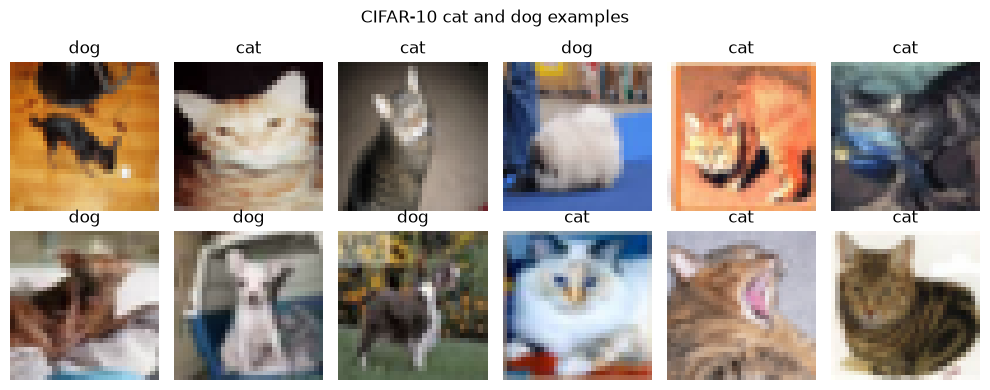

In [3]:
example_ids = rng.choice(len(x_train_all), size=12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, image_id in zip(axes.flat, example_ids):
    ax.imshow(x_train_all[image_id])
    ax.set_title(CLASS_NAMES[y_train_all[image_id]])
    ax.axis("off")
plt.suptitle("CIFAR-10 cat and dog examples")
plt.tight_layout()
plt.show()


## 4. Normalize pixels and create a validation set

Dividing by 255 scales each color channel to 0–1. We also keep part of the training data aside for validation, so the model is checked on images it did not fit.


In [4]:
x_train_all = x_train_all.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train, x_val, y_train, y_val = train_test_split(
    x_train_all,
    y_train_all,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_all,
)
print("Train:", x_train.shape, "Validation:", x_val.shape, "Test:", x_test.shape)


Train: (8500, 32, 32, 3) Validation: (1500, 32, 32, 3) Test: (2000, 32, 32, 3)


## 5. Build the CNN

Convolution layers look for local visual patterns such as edges and textures. Pooling reduces the image size, while dropout makes memorizing the training set a little harder.


In [5]:
augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
    ],
    name="augmentation",
)

model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(32, 32, 3)),
        augmentation,
        tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(96, 3, activation="relu", padding="same"),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ],
    name="cat_dog_cnn",
)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


Model: "cat_dog_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,881 (292.50 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the model

The model trains for ten epochs with early stopping. A GPU runtime in Colab will make this section noticeably faster.


In [6]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=2, restore_best_weights=True
        )
    ],
    verbose=2,
)


Epoch 1/10


133/133 - 2s - 15ms/step - accuracy: 0.5291 - loss: 0.6899 - val_accuracy: 0.5513 - val_loss: 0.6828


Epoch 2/10


133/133 - 2s - 12ms/step - accuracy: 0.5851 - loss: 0.6726 - val_accuracy: 0.6087 - val_loss: 0.6633


Epoch 3/10


...

133/133 - 2s - 12ms/step - accuracy: 0.6879 - loss: 0.5897 - val_accuracy: 0.6673 - val_loss: 0.6117


Epoch 9/10


133/133 - 2s - 12ms/step - accuracy: 0.6982 - loss: 0.5777 - val_accuracy: 0.6860 - val_loss: 0.5910


Epoch 10/10


133/133 - 2s - 12ms/step - accuracy: 0.7042 - loss: 0.5719 - val_accuracy: 0.6900 - val_loss: 0.5828


## 7. Plot how training changed

Accuracy should rise and loss should fall. If validation curves stop improving while training keeps improving, the model may be overfitting.


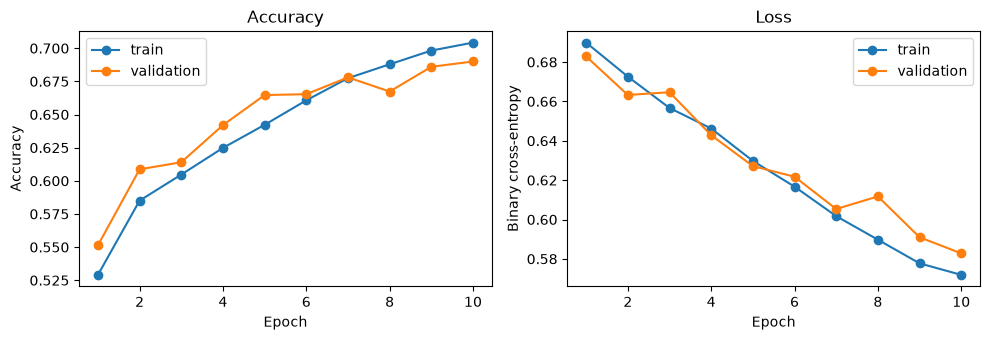

In [7]:
epochs = range(1, len(history.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(epochs, history.history["accuracy"], marker="o", label="train")
axes[0].plot(epochs, history.history["val_accuracy"], marker="o", label="validation")
axes[0].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[0].legend()

axes[1].plot(epochs, history.history["loss"], marker="o", label="train")
axes[1].plot(epochs, history.history["val_loss"], marker="o", label="validation")
axes[1].set(title="Loss", xlabel="Epoch", ylabel="Binary cross-entropy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Evaluate on held-out images

Test accuracy is a summary, but looking at predicted images shows what that number means. Green titles are correct; red titles are mistakes.


Test loss: 0.579
Test accuracy: 70.1%


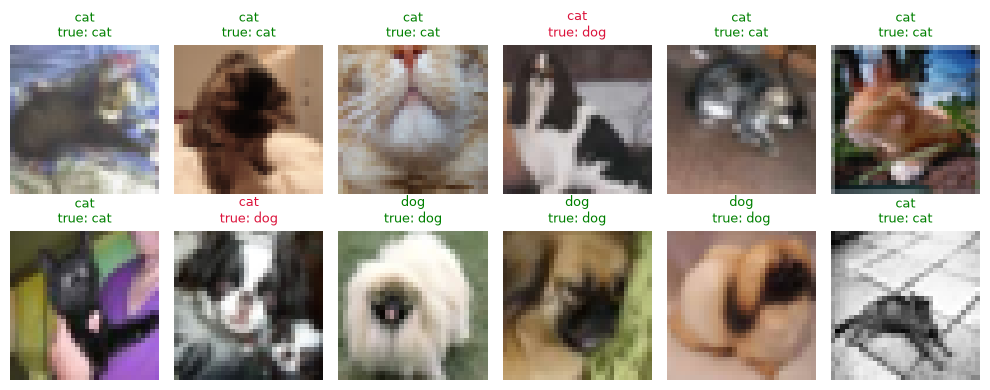

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
probabilities = model.predict(x_test, verbose=0).ravel()
predictions = (probabilities >= 0.5).astype("int32")
print(f"Test loss: {test_loss:.3f}")
print(f"Test accuracy: {test_accuracy:.1%}")

preview_ids = rng.choice(len(x_test), size=12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, image_id in zip(axes.flat, preview_ids):
    correct = predictions[image_id] == y_test[image_id]
    ax.imshow(x_test[image_id])
    ax.set_title(
        f"{CLASS_NAMES[predictions[image_id]]}\ntrue: {CLASS_NAMES[y_test[image_id]]}",
        color="green" if correct else "crimson",
        fontsize=9,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()


## 9. Predict one image

The sigmoid output is the model's estimated probability for the dog class. It is not a guarantee, especially for blurry or unusual images.


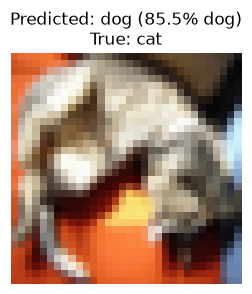

In [9]:
example_index = 7
dog_probability = float(probabilities[example_index])
predicted_label = int(dog_probability >= 0.5)

plt.figure(figsize=(3, 3))
plt.imshow(x_test[example_index])
plt.title(
    f"Predicted: {CLASS_NAMES[predicted_label]} ({dog_probability:.1%} dog)\n"
    f"True: {CLASS_NAMES[y_test[example_index]]}"
)
plt.axis("off")
plt.show()


## Try next

Increase the sample size, add a confusion matrix, or switch to the full cats-vs-dogs dataset after learning how to handle larger downloads. Never deploy an image classifier without testing it on the images it will actually see.
